In [4]:
# Importing the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# 1. Data Filtering

# Reading the dataset
from google.colab import drive
drive.mount('/content/drive')

data_all_states = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/clustering_data.csv")
data_all_states.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_14153/1965934241.py:7: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data_all_states = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/clustering_data.csv")


,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
0,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Peddakotla B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.5689,77.85624
1,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Pinnadhari B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.5281,77.857014
2,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Yerraguntapalle B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.561111,77.85715
3,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Obulareddipalli B.O,515581,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.2488,78.2588
4,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Odulapalli B.O,515581,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.24555,78.2477


In [6]:
# Extracting the entries corresponding to my home state (Maharashtra)
data_intermediate1 = data_all_states[data_all_states["StateName"] == "MAHARASHTRA"].copy()
data_intermediate1.head()

,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
934,Maharashtra Circle,Nagpur Region,Amaravati Division,Bhatkuli S.O,444602,PO,Non Delivery,AMRAVATI,MAHARASHTRA,20.907,77.6026
37630,Maharashtra Circle,Nagpur Region,Chandrapur Division,Subai B.O,442905,BO,Delivery,CHANDRAPUR,MAHARASHTRA,19.5733438,79.4422593
37631,Maharashtra Circle,Nagpur Region,Chandrapur Division,Tembhuwahi B.O,442905,BO,Delivery,CHANDRAPUR,MAHARASHTRA,19.6924335,79.3571161
37632,Maharashtra Circle,Nagpur Region,Chandrapur Division,Vihirgaon B.O,442905,BO,Delivery,CHANDRAPUR,MAHARASHTRA,19.7268087,79.453512
38709,Maharashtra Circle,Aurangabad Region,Osmanabad Division,Nilegaon B.O,413603,BO,Delivery,OSMANABAD,MAHARASHTRA,18.010041,76.0710641


In [7]:
# Checking for missing values
data_intermediate1["Latitude"] = pd.to_numeric(data_intermediate1["Latitude"], errors='coerce')
data_intermediate1["Longitude"] = pd.to_numeric(data_intermediate1["Longitude"], errors='coerce')
print("Shape of the dataset:")
print(data_intermediate1.shape)
print()
print("Do null values exist?")
print(data_intermediate1.isna().any(axis=0))
print()
print("How many null values per column?")
print(data_intermediate1.isna().sum())
print()
print("What percentage of each column is of null values?")
print((data_intermediate1.isna().sum()/data_intermediate1.shape[0])*100)

# Since only about 6% of the records have null values, handling the missing values by dropping them is reasonable
data_intermediate2 = data_intermediate1.dropna().copy()

Shape of the dataset:
(12756, 11)

Do null values exist?
CircleName      False
RegionName      False
DivisionName    False
OfficeName      False
Pincode         False
OfficeType      False
Delivery        False
District        False
StateName       False
Latitude         True
Longitude        True
dtype: bool

How many null values per column?
CircleName        0
RegionName        0
DivisionName      0
OfficeName        0
Pincode           0
OfficeType        0
Delivery          0
District          0
StateName         0
Latitude        772
Longitude       785
dtype: int64

What percentage of each column is of null values?
CircleName      0.000000
RegionName      0.000000
DivisionName    0.000000
OfficeName      0.000000
Pincode         0.000000
OfficeType      0.000000
Delivery        0.000000
District        0.000000
StateName       0.000000
Latitude        6.052054
Longitude       6.153967
dtype: float64


In [8]:
# Checking for duplicates
print("Shape of the dataset after dropping the rows with null values:")
print(data_intermediate2.shape)
print()
print("Do any duplicates exist?")
print(data_intermediate2.duplicated().any())
print()
print("How may rows are duplicates?")
print(data_intermediate2.duplicated().sum())

# Since only one row is a duplicate, we can simply drop it
data = data_intermediate2.drop_duplicates().copy()

Shape of the dataset after dropping the rows with null values:
(11970, 11)

Do any duplicates exist?
True

How may rows are duplicates?
1


In [9]:
# Verifying if the cleaned data indeed has no missing values and also no duplicates
print("Does the cleaned data have any missing value?")
print(data.isna().any())
print()
print("Does the cleaned data have any duplicates?")
print(data.duplicated().any())
print()
print("Shape of the filtered data:")
print(data.shape)

Does the cleaned data have any missing value?
CircleName      False
RegionName      False
DivisionName    False
OfficeName      False
Pincode         False
OfficeType      False
Delivery        False
District        False
StateName       False
Latitude        False
Longitude       False
dtype: bool

Does the cleaned data have any duplicates?
False

Shape of the filtered data:
(11969, 11)


In [10]:
# Cleaned dataset
data.head()

,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
934,Maharashtra Circle,Nagpur Region,Amaravati Division,Bhatkuli S.O,444602,PO,Non Delivery,AMRAVATI,MAHARASHTRA,20.907000,77.602600
37630,Maharashtra Circle,Nagpur Region,Chandrapur Division,Subai B.O,442905,BO,Delivery,CHANDRAPUR,MAHARASHTRA,19.573344,79.442259
37631,Maharashtra Circle,Nagpur Region,Chandrapur Division,Tembhuwahi B.O,442905,BO,Delivery,CHANDRAPUR,MAHARASHTRA,19.692433,79.357116
37632,Maharashtra Circle,Nagpur Region,Chandrapur Division,Vihirgaon B.O,442905,BO,Delivery,CHANDRAPUR,MAHARASHTRA,19.726809,79.453512
38709,Maharashtra Circle,Aurangabad Region,Osmanabad Division,Nilegaon B.O,413603,BO,Delivery,OSMANABAD,MAHARASHTRA,18.010041,76.071064


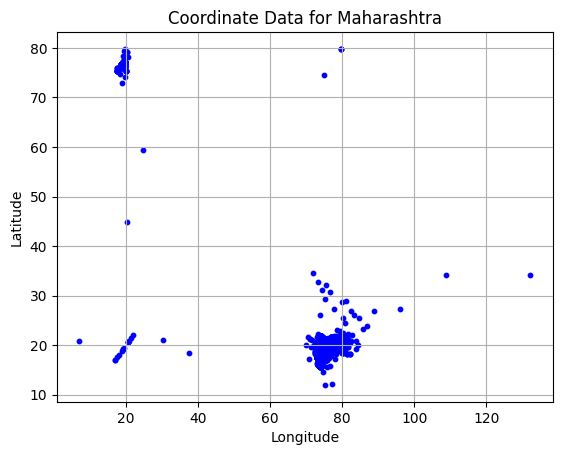

In [11]:
# 2. Data Visualization

# Plotting the longitude on the x axis and the lattitude on the y axis
plt.scatter(data["Longitude"], data["Latitude"], color='blue', s=10)
plt.title("Coordinate Data for Maharashtra")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [12]:
# 3. Clustering Analysis

# Random seed for reproducibility
np.random.seed(42)

# Defining the k_means class
class k_means:
  # Initializing the class
  def __init__(self, k, iterations):
    self.k = k
    self.iterations = iterations
    self.sse_history = None
    self.centroids = None
    self.cluster_assignment = None

  # Implementing the clustering algorithm
  def cluster(self, X):
    self.X = X.values
    self.sse_history = []

    # Initializing k random centroids
    self.centroids = []
    for i in range(self.k):
      initial_centroid = []
      for j in range(self.X.shape[1]):
        random_coordinate = np.random.default_rng().uniform(self.X[:, j].min(), self.X[:, j].max())
        initial_centroid.append(random_coordinate)
      self.centroids.append(initial_centroid)

    # Iteratively updating the centroids and the Sum of Squared Errors
    for iteration in range(self.iterations):
      # Asigning each point to its closest centroid
      self.cluster_assignment = [0]*self.X.shape[0]
      for i in range(self.X.shape[0]):
        min_distance = float("inf")
        for j in range(self.k):
          distance = np.linalg.norm(self.X[i] - self.centroids[j])
          if distance < min_distance:
            min_distance = distance
            self.cluster_assignment[i] = j

      # Finding the Sum of Squared Errors (SSE) for this iteration
      sse = 0;
      for i in range(self.X.shape[0]):
        sse += np.linalg.norm(self.X[i] - self.centroids[self.cluster_assignment[i]])**2
      self.sse_history.append(sse)

      # Calculating the new centroids
      zero_point = [0]*self.X.shape[1]
      new_centroids = [zero_point]*self.k
      for i in range(self.X.shape[0]):
        new_centroids[self.cluster_assignment[i]] += self.X[i]
      for i in range(self.k):
        count = np.sum(np.array(self.cluster_assignment) == i)
        new_centroids[i] = new_centroids[i] / count
      self.centroids = new_centroids

  # Returning the final cluster assignments
  def predict(self):
    return self.cluster_assignment

  # Returning the SSE scores
  def sum_sq_err(self):
    return self.sse_history

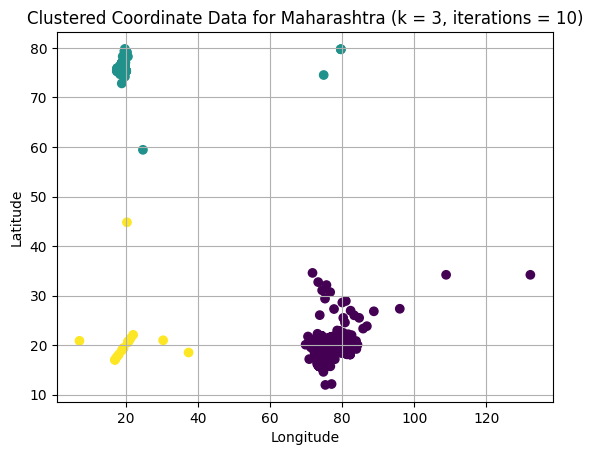

In [16]:
# Creating an instance of the k_means class and analyzing the latitude and longitude data using it
K = 3
ITERATIONS = 10

cluster_alg = k_means(K, ITERATIONS)
X = data[["Latitude", "Longitude"]].copy()
cluster_alg.cluster(X)

# Visualizing the clusters
clusters = cluster_alg.predict()
plt.scatter(data["Longitude"], data["Latitude"], c=clusters)
plt.title(f"Clustered Coordinate Data for Maharashtra (k = {K}, iterations = {ITERATIONS})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()



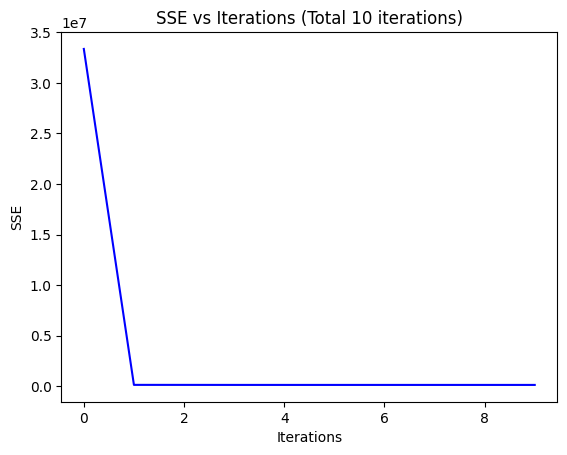

In [14]:
# Plotting the change in the SSE over the iterations
sse_history = cluster_alg.sum_sq_err()
plt.plot(range(ITERATIONS), sse_history, color='blue')
plt.title(f"SSE vs Iterations (Total {ITERATIONS} iterations)")
plt.xlabel("Iterations")
plt.ylabel("SSE")
plt.show()

# An elbow point can be seen at x = 1 (after 2 iterations), suggesting that the
# positions of the centroids converge quickly.

In [15]:
# 4. Inference and Insights

"""

From the scatterplot of the various clusters colored as per their respective
clusters, it is viible that there are a total of three major clusters in the
scatterplot.

The identified clusters are highly dense, as the elbow point for the SSE
occurs fairly early (after just 2 iterations).

Geographically, this indicates that the pincodes in Maharashtra can be broadly
classified into 3 clusters based on their geographic location.

"""

'\n\nFrom the scatterplot of the various clusters colored as per their respective\nclusters, it is viible that there are a total of three major clusters in the\nscatterplot.\n\nThe identified clusters are highly dense, as the elbow point for the SSE\noccurs fairly early (after just 2 iterations).\n\nGeographically, this indicates that the pincodes in Maharashtra can be broadly\nclassified into 3 clusters based on their geographic location.\n\n'